In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_truck_only = pd.read_csv('data/transformed_truck_activities_log.csv', parse_dates=['timestamp', 'timestamp_end'])
df_contingencies = pd.read_csv('data/remapped_contingencies_log.csv', parse_dates=['timestamp', 'timestamp_end'])

cols_to_keep_contingencies = ['case_id', 'activity', 'timestamp', 'timestamp_end']
cols_to_keep_truck = ['case_id', 'activity', 'timestamp', 'timestamp_end']
df_contingencies = df_contingencies[cols_to_keep_contingencies]
df_trucks = df_truck_only[cols_to_keep_truck]

In [3]:
transition_contingencies = ['Colacion comedor', 'Colacion cabina', 'Traslado', 'Traslado a colacion']
assert len(set(transition_contingencies).difference(set(df_contingencies['activity']))) == 0
df_transition_contingencies = df_contingencies[df_contingencies['activity'].isin(transition_contingencies)]

In [4]:
from datetime import datetime 

def find_valid_datetime_range(df_1: pd.DataFrame, df_2: pd.DataFrame) -> tuple[datetime, datetime]:
  """
    Find the common window time that both datasets have information
  """
  low_threshold_datetime = max(df_1['timestamp'].min(), df_2['timestamp'].min())
  high_threshold_datetime = min(df_1['timestamp_end'].max(), df_2['timestamp_end'].max())
  return pd.to_datetime(low_threshold_datetime), pd.to_datetime(high_threshold_datetime)

In [5]:
start_date, end_date = find_valid_datetime_range(df_trucks, df_transition_contingencies)
df_log = pd.concat([df_trucks, df_transition_contingencies])
df_log = df_log[df_log['timestamp'] >= start_date.to_datetime64()]
df_log = df_log[df_log['timestamp_end'] <= end_date.to_datetime64()]
df_log = df_log[df_log['activity'] != 'Efectivo']
df_log = df_log.sort_values(by=['case_id', 'timestamp', 'timestamp_end'])

In [6]:
print(df_log['activity'].unique().tolist())

['Carga', 'Traslado a descarga', 'Descarga', 'Traslado a carga', 'Colacion comedor', 'Colacion cabina', 'Traslado', 'Traslado a colación']


In [7]:
import builtins
# from dfg_filtering import squeeze_consecutive_activities
def squeeze_consecutive_activities(df_log: pd.DataFrame) -> pd.DataFrame:
  """
    Gather the consecutive activities into one keeping the information of the first record
  """
  validate_necessary_pandas_columns(df_log, ['case_id', 'activity', 'timestamp', 'timestamp_end'])
  df_log['dummy_group'] = (df_log['activity'] != df_log['activity'].shift()).cumsum()

  df_squeezed = df_log.groupby('dummy_group').agg({
      'case_id':       'first',
      'activity':      'first',
      'timestamp':     'min',
      'timestamp_end': 'max'
  }).reset_index(drop=True)

  # TODO: Also keep the record of the other columns
  return df_squeezed

def validate_necessary_pandas_columns(df: pd.DataFrame, columns: list[str] | str):
  """
    Raise an AttributeValidation error if the column(s) are not in the pandas DataFrame
  """
  match type(columns):
    case builtins.str:
      print('Is a string')
      if not columns in df.columns:
        AttributeValidation(f'"{columns}" is not in {df.columns.tolist()}')
    case builtins.list:
      print('Is a list')
      columns_difference = set(columns).difference(set(df.columns))
      if not len(columns_difference) == 0:
        AttributeValidation(f'"{columns_difference}" are not in {df.columns.tolist()}')

class AttributeValidation(Exception):
  def __init__(self, message, errors):            
    super().__init__(message)
    self.errors = errors


Is a list


In [8]:
import mpdfg
from dfg_filtering import handle_negatives_times

format_dictionary = {
    'case:concept:name': 'case_id',
    'concept:name': 'activity',
    'start_timestamp': 'timestamp',
    'time:timestamp': 'timestamp_end',
    'cost:total': '',
    'org:resource': '',
}

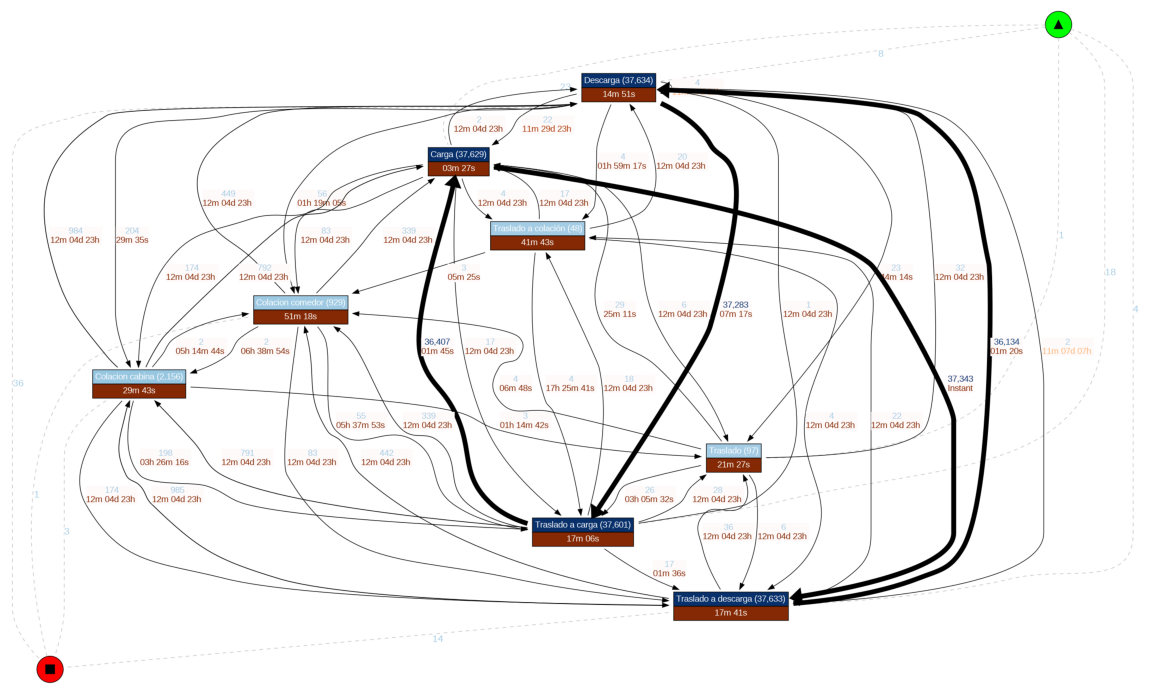

In [9]:
df_log_squeezed = squeeze_consecutive_activities(df_log)
df_formatted_log = mpdfg.log_formatter(log=df_log_squeezed.sort_values(by=['case_id', 'timestamp']), format=format_dictionary)
dfg, start_activities, end_activities = mpdfg.discover_multi_perspective_dfg(log=df_formatted_log, calculate_cost=False)
mpdfg.view_multi_perspective_dfg(dfg, start_activities, end_activities)

In [10]:
from dfg_filtering import format_dfg_to_dataframe, handle_negatives_times,\
                          filter_by_percentile_frequency, generate_filtered_dfg_dict

def remove_not_connected_activities(dfg: dict) -> pd.DataFrame:
  dfg_copy = dfg.copy()
  unique_activities = pd.Series(sum([list(i) for i in dfg['connections'].keys()], [])).unique()
  print(unique_activities)
  dfg_copy['activities'] = { key: value for key, value in dfg['activities'].items() if key in unique_activities }
  return dfg_copy

def filter_start_and_end_activities(dfg, start_activities, end_activities) -> tuple[dict, dict]:
  unique_activities = pd.Series(sum([list(i) for i in dfg['connections'].keys()], [])).unique()
  return ({ key: value for key, value in start_activities.items() if key in unique_activities },
          { key: value for key, value in end_activities.items() if key in unique_activities })

def run_pipeline(dfg: dict, percentile: float, start_activities: dict, end_activities: dict) -> None:
  df_connections = format_dfg_to_dataframe(dfg)
  df_1 = handle_negatives_times(df_connections)
  df_2 = filter_by_percentile_frequency(df_1, percentile)
  dfg_connections_corrected = generate_filtered_dfg_dict(df_2)
  dfg_corrected = dfg.copy()
  dfg_corrected['connections'] = dfg_connections_corrected
  dfg_corrected = remove_not_connected_activities(dfg_corrected)
  start_activities, end_activities = filter_start_and_end_activities(dfg_corrected, start_activities, end_activities)
  print(start_activities, end_activities)
  mpdfg.view_multi_perspective_dfg(dfg_corrected, start_activities, end_activities)
  return dfg_corrected

Is a list
Total rows 36. Filtered a total of 12 rows
['Carga' 'Descarga' 'Colacion comedor' 'Traslado a carga'
 'Colacion cabina' 'Traslado a descarga' 'Traslado' 'Traslado a colación']
{'Carga': 23, 'Traslado a carga': 18, 'Descarga': 8, 'Traslado a descarga': 4, 'Traslado': 1} {'Descarga': 36, 'Traslado a descarga': 14, 'Colacion cabina': 3, 'Colacion comedor': 1}


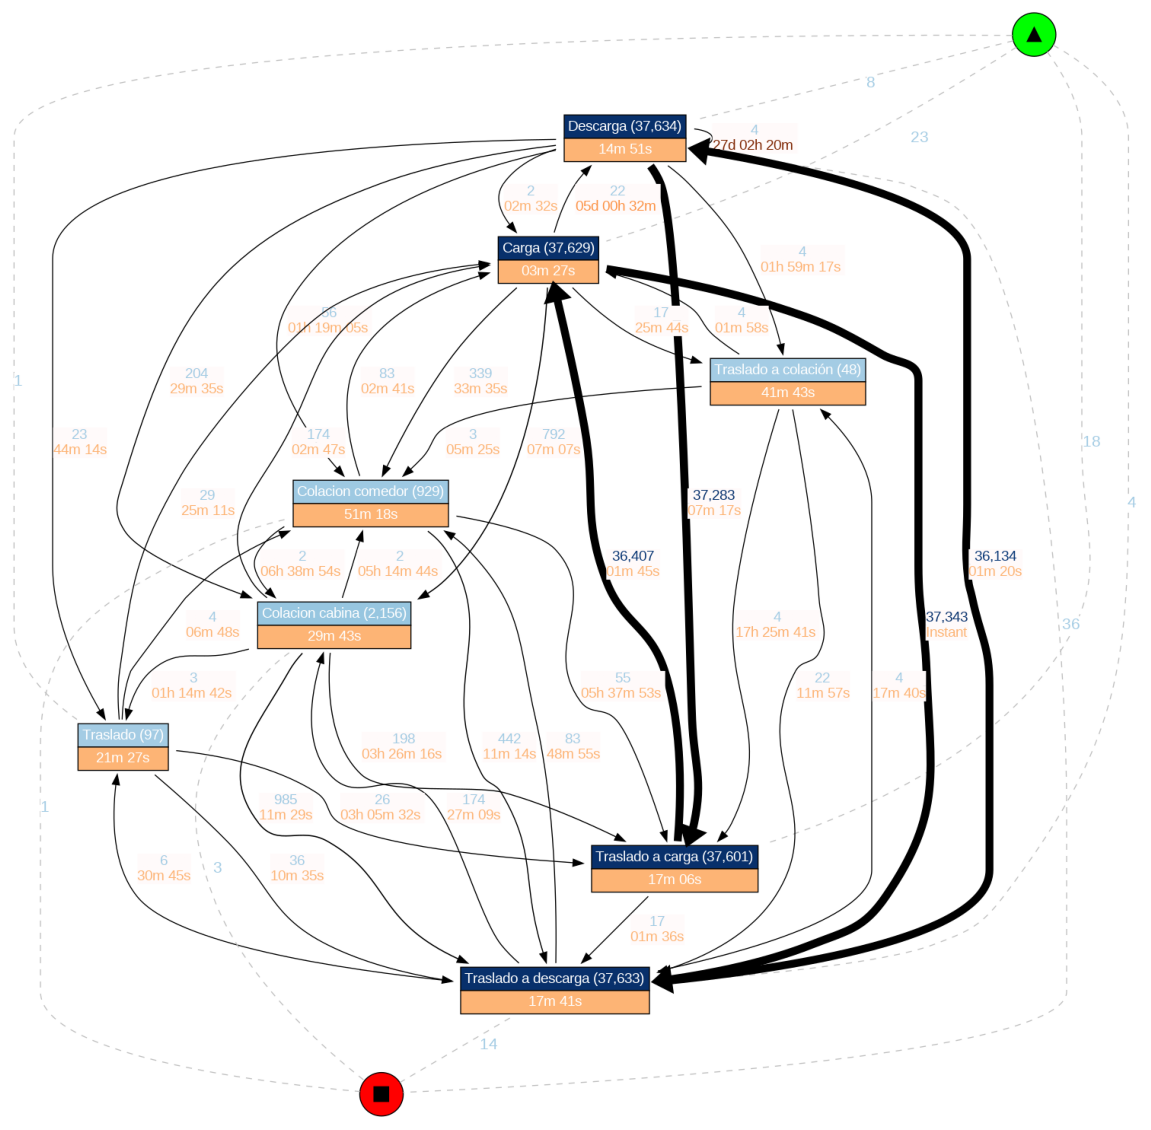

{'activities': {'Descarga': {'frequency': 37634, 'time': 891.66},
  'Carga': {'frequency': 37629, 'time': 207.78},
  'Traslado a descarga': {'frequency': 37633, 'time': 1061.25},
  'Traslado a carga': {'frequency': 37601, 'time': 1026.68},
  'Colacion comedor': {'frequency': 929, 'time': 3078.92},
  'Colacion cabina': {'frequency': 2156, 'time': 1783.46},
  'Traslado': {'frequency': 97, 'time': 1287.44},
  'Traslado a colación': {'frequency': 48, 'time': 2503.81}},
 'connections': {('Carga', 'Descarga'): {'frequency': 22, 'time': 433944.91},
  ('Colacion comedor', 'Traslado a carga'): {'frequency': 55,
   'time': 20273.27},
  ('Carga', 'Colacion comedor'): {'frequency': 339, 'time': 2015.32},
  ('Colacion cabina', 'Traslado a carga'): {'frequency': 198,
   'time': 12376.57},
  ('Carga', 'Colacion cabina'): {'frequency': 792, 'time': 427.06},
  ('Colacion cabina', 'Traslado a descarga'): {'frequency': 985,
   'time': 689.15},
  ('Descarga', 'Colacion cabina'): {'frequency': 204, 'time':

In [11]:
run_pipeline(dfg, 0, start_activities, end_activities)

Is a list
Total rows 36. Filtered a total of 12 rows
['Carga' 'Descarga' 'Colacion comedor' 'Traslado a carga'
 'Colacion cabina' 'Traslado a descarga' 'Traslado' 'Traslado a colación']
{'Carga': 23, 'Traslado a carga': 18, 'Descarga': 8, 'Traslado a descarga': 4, 'Traslado': 1} {'Descarga': 36, 'Traslado a descarga': 14, 'Colacion cabina': 3, 'Colacion comedor': 1}


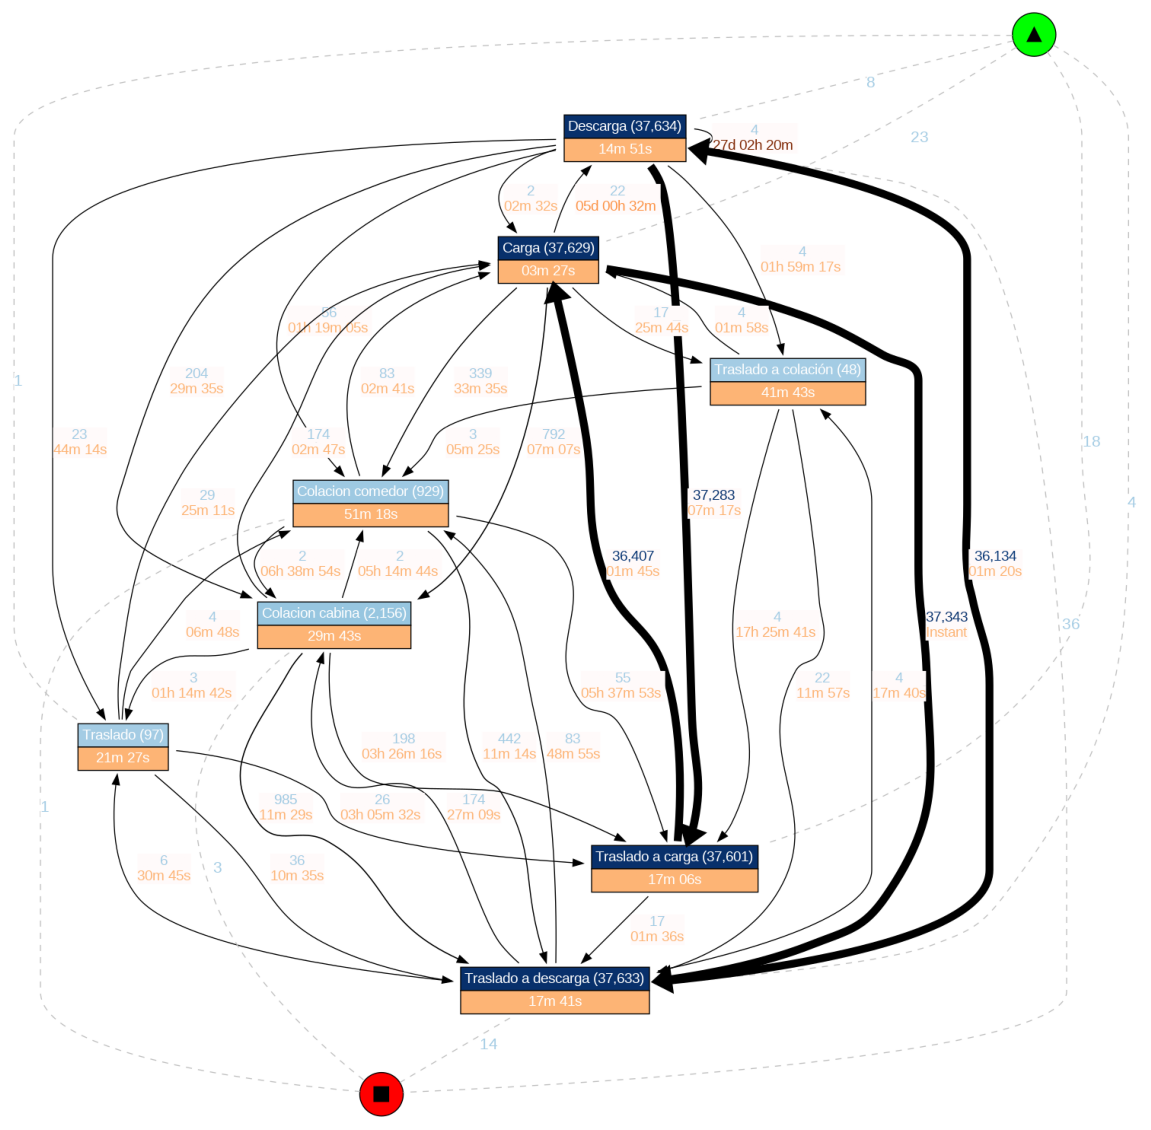

{'activities': {'Descarga': {'frequency': 37634, 'time': 891.66},
  'Carga': {'frequency': 37629, 'time': 207.78},
  'Traslado a descarga': {'frequency': 37633, 'time': 1061.25},
  'Traslado a carga': {'frequency': 37601, 'time': 1026.68},
  'Colacion comedor': {'frequency': 929, 'time': 3078.92},
  'Colacion cabina': {'frequency': 2156, 'time': 1783.46},
  'Traslado': {'frequency': 97, 'time': 1287.44},
  'Traslado a colación': {'frequency': 48, 'time': 2503.81}},
 'connections': {('Carga', 'Descarga'): {'frequency': 22, 'time': 433944.91},
  ('Colacion comedor', 'Traslado a carga'): {'frequency': 55,
   'time': 20273.27},
  ('Carga', 'Colacion comedor'): {'frequency': 339, 'time': 2015.32},
  ('Colacion cabina', 'Traslado a carga'): {'frequency': 198,
   'time': 12376.57},
  ('Carga', 'Colacion cabina'): {'frequency': 792, 'time': 427.06},
  ('Colacion cabina', 'Traslado a descarga'): {'frequency': 985,
   'time': 689.15},
  ('Descarga', 'Colacion cabina'): {'frequency': 204, 'time':

In [12]:
run_pipeline(dfg, 0, start_activities, end_activities)

In [28]:
import warnings
sns.set_theme(style='darkgrid')
warnings.filterwarnings("ignore")

[Text(0.5, 87.24999999999999, 'Hora del día'), Text(144.5, 0.5, 'Frecuencia')]

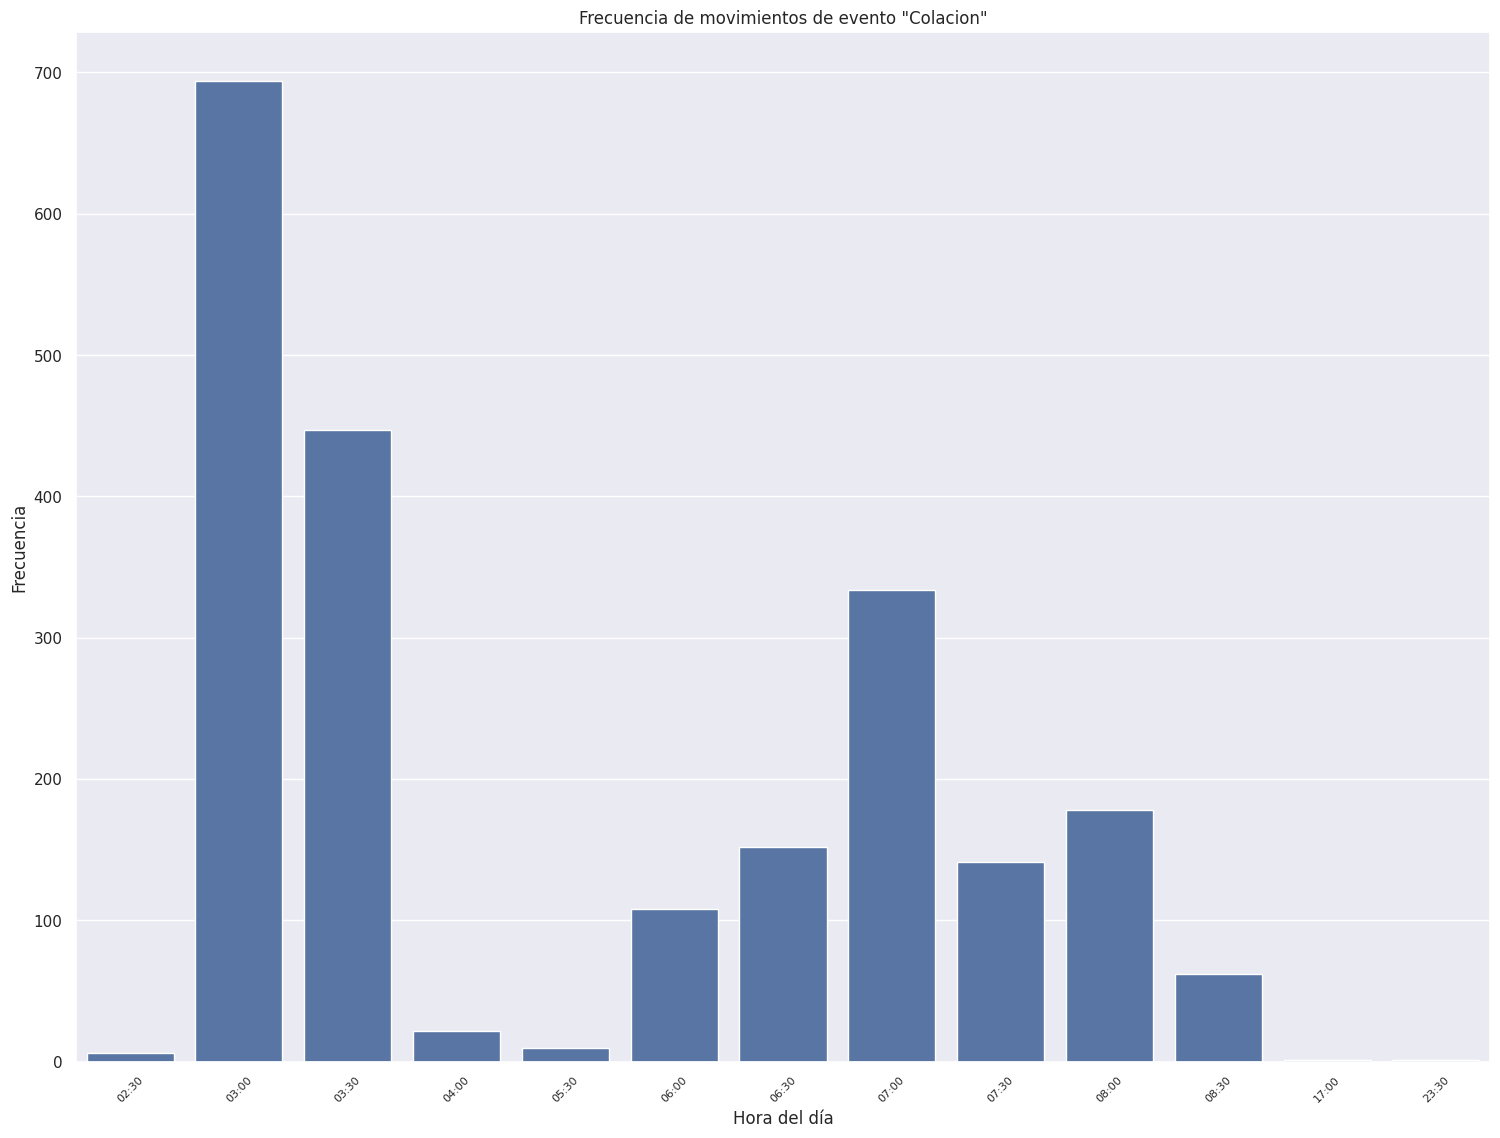

In [36]:
PERIOD = '30min'
TYPE_PLOT = 'hist'
FILTER_ACTIVITY = 'Colacion cabina'
df_colacion = df_log_squeezed[df_log_squeezed['activity'].isin([FILTER_ACTIVITY])]
df_colacion['truncated_ts'] = df_colacion['timestamp'].dt.floor(PERIOD)
df_colacion['format_hour'] = df_colacion['truncated_ts'].dt.strftime('%H:%M')
df_colacion['hour_sorted'] = df_colacion['truncated_ts'].dt.strftime('%H.%M').astype(float)
df_colacion['hour_sorted'] = df_colacion['hour_sorted'].astype(int) + (df_colacion['hour_sorted'] % 1) * 10 / 6

unique_ticks = df_colacion[['hour_sorted', 'format_hour']].drop_duplicates().sort_values(by='hour_sorted')
# Start figures
fig, ax1 = plt.subplots(figsize=(15, 11), ncols=1, nrows=1)
fig.tight_layout(h_pad=5)
# if TYPE_PLOT == 'hist':
#   sns.countplot(data=df_colacion, x='hour_sorted', y='timediff', ax=ax1)
# else:
#   sns.boxplot(data=df_colacion, x='hour_sorted', y='timediff', ax=ax1, fliersize=0)
#   ax1.set(ylim=(0, df_colacion['timediff'].quantile(0.925) * 1.25))

# ax1.set_title(f'Bar plot with mean in {origin_destination}')
# ax1.set_xticklabels(unique_ticks['format_hour'], rotation=45, fontsize=8)
# ax1.set(xlabel="Hora de día", ylabel="Tiempo de ciclo")
sns.countplot(data=df_colacion, x='hour_sorted', ax=ax1)
ax1.set_title(f'Frecuencia de movimientos de evento "Colacion"')
ax1.set_xticklabels(unique_ticks['format_hour'], rotation=45, fontsize=8)
ax1.set(xlabel="Hora del día", ylabel="Frecuencia");